In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [13]:
file_path = "./Lenna_(test_image).png"

img = Image.open(file_path)
img_array = np.array(img)

In [14]:
print(img_array.shape)
print(img_array.dtype)

(512, 512, 3)
uint8


$$f(x, y) = e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

In [15]:
def gussian_kernel(size=3, sigma=1.0):
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel

gussian_kernel(size=3, sigma=1.0)

array([[0.07511361, 0.12384141, 0.07511361],
       [0.12384141, 0.20417996, 0.12384141],
       [0.07511361, 0.12384141, 0.07511361]], dtype=float32)

In [16]:
def convolve2d(image, kernel):
    img_h, img_w, img_c = image.shape
    ker_h, ker_w = kernel.shape
    pad_h = ker_h // 2
    pad_w = ker_w // 2

    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='symmetric')

    output = np.zeros_like(image, dtype=np.float32)
    for c in range(img_c):
        for i in range(img_h):
            for j in range(img_w):
                region = padded_image[i:i+ker_h, j:j+ker_w, c]
                output[i, j, c] = np.sum(region * kernel)

    output = np.clip(output, 0, 255)

    return output

In [17]:
def downsample(image):
    return image[::2, ::2]

def upsample(image):
    img_h, img_w, img_c = image.shape
    upsampled = np.zeros((img_h * 2, img_w * 2, img_c), dtype=image.dtype)
    upsampled[::2, ::2] = image
    return upsampled

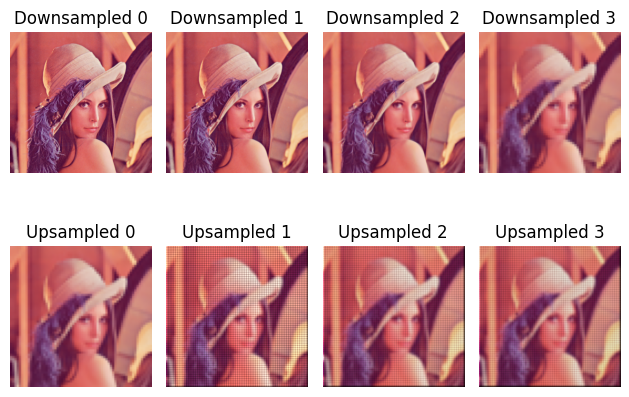

In [21]:
kernel = gussian_kernel(size=3, sigma=1.0)

downsamples = [img_array]


for _ in range(3):
    down_blurred_img = convolve2d(downsamples[-1], kernel)
    downsampled_img = downsample(down_blurred_img)
    downsamples.append(downsampled_img)

upsamples = [downsamples[-1]]

for _ in range(3):
    upsampled_img = upsample(upsamples[-1])
    up_blurred_img = convolve2d(upsampled_img, kernel*4)
    
    upsamples.append(up_blurred_img)

for i, downsampled in enumerate(downsamples):
    plt.subplot(2, 4, i + 1)
    plt.imshow(downsampled.astype(np.uint8))
    plt.title(f"Downsampled {i}")
    plt.axis('off')
for i, upsampled in enumerate(upsamples):
    plt.subplot(2, 4, i + 5)
    plt.imshow(upsampled.astype(np.uint8))
    plt.title(f"Upsampled {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()